📌 Extração






In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [24]:
df = pd.read_csv("/content/churn_telecom.csv")
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias,rango_tenure
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,One year,Yes,Mailed check,65.6,593.3,2.186667,7-12
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,Month-to-month,No,Mailed check,59.9,542.4,1.996667,7-12
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,0-6
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,13-24
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4,2.796667,0-6


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   Contract          7267 non-null   object 
 10  PaperlessBilling  7267 non-null   object 
 11  PaymentMethod     7267 non-null   object 
 12  Charges.Monthly   7267 non-null   float64
 13  Charges.Total     7267 non-null   object 
 14  Contas_Diarias    7267 non-null   float64
 15  rango_tenure      7256 non-null   object 
dtypes: float64(2), int64(2), object(12)
memory

🔧 Preparação dos dados

In [26]:
# Eliminar colunas
df = df.drop(['customerID', 'rango_tenure', 'Contas_Diarias'], axis=1)

In [28]:
df.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [29]:
#Revisão de colunas
cols_to_fix = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'
]

for col in cols_to_fix:
    if col in df.columns:
        display(df[col].value_counts(dropna=False))
        display("-" * 30)

,count
PhoneService,
Yes,6560
No,707


'------------------------------'

,count
MultipleLines,
No,3495
Yes,3065
No phone service,707


'------------------------------'

,count
Contract,
Month-to-month,4005
Two year,1743
One year,1519


'------------------------------'

,count
PaperlessBilling,
Yes,4311
No,2956


'------------------------------'

,count
PaymentMethod,
Electronic check,2445
Mailed check,1665
Bank transfer (automatic),1589
Credit card (automatic),1568


'------------------------------'

In [30]:
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Criando df_clean by copying df
df_clean = df.copy()

for col in cols_to_fix:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace('No internet service', 'No')

categorical_cols = [
    'Churn', 'gender', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

🔡 ➡️ 🔢 Encoding

In [31]:
# Selecionar as colunas categóricas
columnas_categoricas_clean = df_clean.select_dtypes(include='object').columns.tolist()
columnas_categoricas_clean.remove('Churn')

# Aplicar codificação one-hot no DataFrame
df_codificado_clean = pd.get_dummies(df_clean, columns=columnas_categoricas_clean, drop_first=True)

# Codificar a variavel 'Churn'
df_codificado_clean['Churn'] = df_codificado_clean['Churn'].map({'No': 0, 'Yes': 1})
df_codificado_clean.info()
df_codificado_clean

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Columns: 6546 entries, Churn to Charges.Total_999.9
dtypes: bool(6542), float64(2), int64(2)
memory usage: 45.6 MB


,Churn,SeniorCitizen,tenure,Charges.Monthly,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Charges.Total_995.35,Charges.Total_996.45,Charges.Total_996.85,Charges.Total_996.95,Charges.Total_997.65,Charges.Total_997.75,Charges.Total_998.1,Charges.Total_999.45,Charges.Total_999.8,Charges.Total_999.9
0,0.0,0,9,65.60,False,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.0,0,9,59.90,True,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
2,1.0,0,4,73.90,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1.0,1,13,98.00,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1.0,1,3,83.90,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,0,13,55.15,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7263,1.0,0,22,85.10,True,True,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False
7264,0.0,0,2,50.30,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
7265,0.0,0,67,67.85,True,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,False


◔ Prpporção de clientes que cancelaram

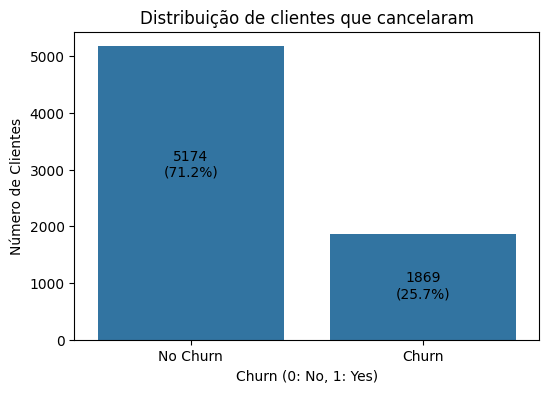

In [33]:
# Visualizar a distribução de clientes que cancelaram
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Churn', data=df_codificado_clean)
plt.title('Distribuição de clientes que cancelaram')
plt.xlabel('Churn (0: No, 1: Yes)')
plt.ylabel('Número de Clientes')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])

# incluir valores e proporções
total = len(df_codificado_clean)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height * 0.65,
            '{:d}\n({:.1f}%)'.format(int(height), 100*height/total),
            ha="center", va="top")

plt.show()


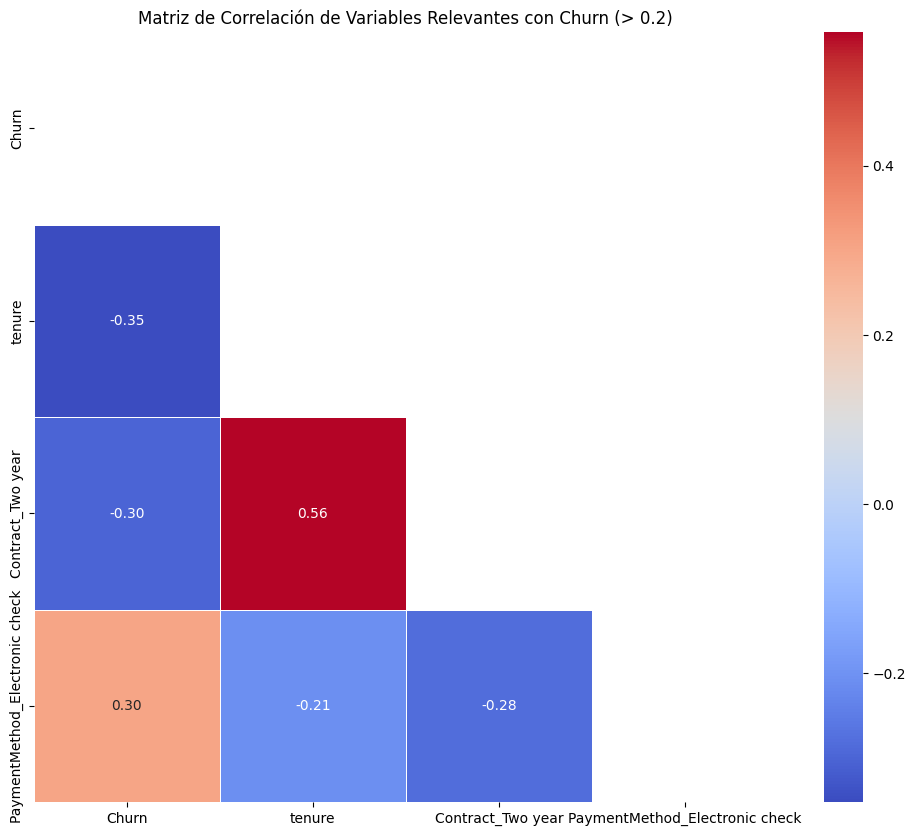

In [34]:
# Definir a variavel
target_var = 'Churn'

limiar = 0.2

# Calcular a matriz de correlação
correlation_matrix_original = df_codificado_clean.corr()

variables_relevantes = correlation_matrix_original.index[abs(correlation_matrix_original[target_var]) >= limiar].tolist()

if target_var not in variables_relevantes:
    variables_relevantes.append(target_var)

# Criar uma matriz com as variaveis seleccionadas
corr_filtrada = correlation_matrix_original.loc[variables_relevantes, variables_relevantes]

mascara = np.triu(np.ones_like(corr_filtrada, dtype=bool))

# Criar uma marcara para melhor visualização
plt.figure(figsize=(12,10))
sns.heatmap(corr_filtrada, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, mask=mascara)
plt.title('Matriz de Correlação de Variaveis Relevantes con Churn (> 0.2)')
plt.show()


⚖️ Balançode Classes

In [35]:
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar características (X) e variável alvo (y) do DataFrame codificado e limpo
# Selecionar apenas as variáveis relevantes identificadas pela análise de correlação
X_limpo = df_codificado_limpo[variaveis_relevantes].drop('Churn', axis=1)
y_limpo = df_codificado_limpo['Churn']

# Mostrar a distribuição original das classes
display("Distribuição original das classes (DataFrame limpo e codificado, variáveis relevantes):")
display(Counter(y_limpo))

# Dividir os dados originais em conjuntos de treino e teste (usando apenas as variáveis relevantes)
X_treino_limpo, X_teste_limpo, y_treino_limpo, y_teste_limpo = train_test_split(
    X_limpo, y_limpo, test_size=0.25, random_state=42, stratify=y_limpo
)

# Mostrar as dimensões dos conjuntos resultantes antes do balanceamento
display("Dimensões do conjunto de treino (X_treino_limpo, y_treino_limpo) antes do balanceamento (variáveis relevantes):")
display(X_treino_limpo.shape, y_treino_limpo.shape)

display("Dimensões do conjunto de teste (X_teste_limpo, y_teste_limpo) antes do balanceamento (variáveis relevantes):")
display(X_teste_limpo.shape, y_teste_limpo.shape)

# Aplicar SMOTE apenas ao conjunto de treino
smote_limpo = SMOTE(random_state=42)
X_treino_balanceado_limpo, y_treino_balanceado_limpo = smote_limpo.fit_resample(X_treino_limpo, y_treino_limpo)

# Mostrar a nova distribuição das classes após aplicar SMOTE
display("Distribuição das classes no conjunto de treino após aplicar SMOTE (DataFrame limpo, variáveis relevantes):")
display(Counter(y_treino_balanceado_limpo))

# Identificar as colunas numéricas no conjunto de treino balanceado
# Garantir que apenas colunas numéricas/int sejam selecionadas antes da padronização
colunas_numericas_limpo = X_treino_balanceado_limpo.select_dtypes(include=['float64', 'int64']).columns.tolist()

NameError: name 'df_codificado_limpo' is not defined

📏 Características Numéricas

In [ ]:
# Padronizar as características numéricas *após* o balanceamento e *separadamente* para treino e teste

# Inicializar o StandardScaler
scaler_limpo = StandardScaler()

# Aplicar padronização ao conjunto de treino balanceado
# Padronizar apenas as colunas numéricas selecionadas
X_treino_balanceado_limpo[colunas_numericas_limpo] = scaler_limpo.fit_transform(
    X_treino_balanceado_limpo[colunas_numericas_limpo]
)

# Aplicar a mesma padronização ao conjunto de teste
# Padronizar apenas as colunas numéricas selecionadas
X_teste_limpo[colunas_numericas_limpo] = scaler_limpo.transform(
    X_teste_limpo[colunas_numericas_limpo]
)

# Mostrar as primeiras linhas dos conjuntos padronizados
display("Primeiras linhas do conjunto de treino balanceado e padronizado (DataFrame limpo, variáveis relevantes):")
display(X_treino_balanceado_limpo.head())

display("Primeiras linhas do conjunto de teste padronizado (DataFrame limpo, variáveis relevantes):")
display(X_teste_limpo.head())

📈 Análise da Relação entre Variaveis Específicas e
 Churn

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Relação entre Tipo de Contrato, Gasto Total e Churn

plt.figure(figsize=(10, 6))
sns.boxplot(x='Contract', y='Charges.Total', hue='Churn', data=df_limpo)
plt.title('Gasto Total por Tipo de Contrato e Churn')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Gasto Total')
plt.show()

# Relação entre Gasto Total e Churn
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='Charges.Total', data=df_limpo)
plt.title('Gasto Total por Churn')
plt.xlabel('Churn')
plt.ylabel('Gasto Total')
plt.show()

Modelo Predictivo

In [ ]:
#Regressão Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializar o modelo de Regressão Logística
modelo_regressao_logistica_limpo = LogisticRegression(random_state=42, solver='liblinear')

# Treinar o modelo com os dados de treino balanceados e padronizados (limpos e com variáveis relevantes)
modelo_regressao_logistica_limpo.fit(X_treino_balanceado_limpo, y_treino_balanceado_limpo)

# Fazer previsões no conjunto de teste padronizado (limpo e com variáveis relevantes)
y_pred_limpo = modelo_regressao_logistica_limpo.predict(X_teste_limpo)

# Avaliar o modelo
display("Avaliação do modelo de Regressão Logística (com dados limpos, balanceados e variáveis relevantes):")
display(f"Accuracy: {accuracy_score(y_teste_limpo, y_pred_limpo):.4f}")

# Relatório de Classificação em formato de tabela
relatorio_classificacao_dict = classification_report(y_teste_limpo, y_pred_limpo, output_dict=True)
relatorio_classificacao_df = pd.DataFrame(relatorio_classificacao_dict).transpose()
display("------------------------------------------- Relatório de Classificação: --------------------------------------------")
display(relatorio_classificacao_df)

# Calcular a matriz de confusão
cm_limpo = confusion_matrix(y_teste_limpo, y_pred_limpo)

# Matriz de Confusão em formato de tabela
cm_df = pd.DataFrame(
    cm_limpo,
    index=['Valor Real: Não Churn (0)', 'Valor Real: Churn (1)'],
    columns=['Predição: Não Churn (0)', 'Predição: Churn (1)']
)
display("------------------------------------------- Matriz de Confusão: --------------------------------------------")
display(cm_df)

# Visualização da matriz de confusão (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_limpo,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Não Churn (0)', 'Churn (1)'],
    yticklabels=['Não Churn (0)', 'Churn (1)']
)
plt.xlabel('Predição do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão do Modelo de Regressão Logística (Dados Limpos e Variáveis Relevantes)')
plt.show()

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Inicializar o modelo de Random Forest
modelo_random_forest = RandomForestClassifier(random_state=42)

# Treinar o modelo com os dados de treino balanceados e padronizados
modelo_random_forest.fit(X_treino_balanceado_limpo, y_treino_balanceado_limpo)

# Fazer previsões no conjunto de teste padronizado
y_pred_rf = modelo_random_forest.predict(X_teste_limpo)

# Avaliar o modelo
display("Avaliação do modelo de Random Forest:")
display(f"Accuracy: {accuracy_score(y_teste_limpo, y_pred_rf):.4f}")

# Relatório de Classificação em formato de tabela
relatorio_classificacao_rf_dict = classification_report(y_teste_limpo, y_pred_rf, output_dict=True)
relatorio_classificacao_rf_df = pd.DataFrame(relatorio_classificacao_rf_dict).transpose()
display("------------------------------------------- Relatório de Classificação (Random Forest): --------------------------------------------")
display(relatorio_classificacao_rf_df)

# Calcular a matriz de confusão
cm_rf = confusion_matrix(y_teste_limpo, y_pred_rf)

# Matriz de Confusão em formato de tabela
cm_rf_df = pd.DataFrame(
    cm_rf,
    index=['Valor Real: Não Churn (0)', 'Valor Real: Churn (1)'],
    columns=['Predição: Não Churn (0)', 'Predição: Churn (1)']
)
display("------------------------------------------- Matriz de Confusão (Random Forest): --------------------------------------------")
display(cm_rf_df)

# Visualização da matriz de confusão (heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Não Churn (0)', 'Churn (1)'],
    yticklabels=['Não Churn (0)', 'Churn (1)']
)
plt.xlabel('Predição do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão do Modelo de Random Forest')
plt.show()

🔍Evaluación de los Modelos

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd

# Criar um dicionário para armazenar as métricas relevantes de cada modelo
comparacao_metricas = {
    'Modelo': ['Regressão Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_teste_limpo, y_pred_limpo),
                 accuracy_score(y_teste_limpo, y_pred_rf),
                 accuracy_score(y_teste_limpo, y_pred_xgb)],
    'Precisão (Churn)': [relatorio_classificacao_dict['1']['precision'],
                         relatorio_classificacao_rf_dict['1']['precision'],
                         relatorio_classificacao_xgb_dict['1']['precision']],
    'Recall (Churn)': [relatorio_classificacao_dict['1']['recall'],
                       relatorio_classificacao_rf_dict['1']['recall'],
                       relatorio_classificacao_xgb_dict['1']['recall']],
    'F1-score (Churn)': [relatorio_classificacao_dict['1']['f1-score'],
                         relatorio_classificacao_rf_dict['1']['f1-score'],
                         relatorio_classificacao_xgb_dict['1']['f1-score']],
    'AUC-ROC': [roc_auc_score(y_teste_limpo, modelo_regressao_logistica_limpo.predict_proba(X_teste_limpo)[:, 1]),
                roc_auc_score(y_teste_limpo, modelo_random_forest.predict_proba(X_teste_limpo)[:, 1]),
                roc_auc_score(y_teste_limpo, modelo_xgb.predict_proba(X_teste_limpo)[:, 1])]
}

# Criar um DataFrame com as métricas comparadas
df_comparacao = pd.DataFrame(comparacao_metricas)

# Formatar as colunas numéricas para melhor leitura
colunas_formatadas = ['Accuracy', 'Precisão (Churn)', 'Recall (Churn)', 'F1-score (Churn)', 'AUC-ROC']
df_comparacao[colunas_formatadas] = df_comparacao[colunas_formatadas].applymap('{:.4f}'.format)

# Mostrar a tabela comparativa
display(df_comparacao)

⚙️Avaliação dos Modelos no Conjunto de Treino

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# --- Avaliação do Modelo de Regressão Logística no Conjunto de Treino ---
display("Avaliação do modelo de Regressão Logística (Conjunto de Treino Balanceado):")

# Previsões no conjunto de treino
y_treino_pred_lr = modelo_regressao_logistica_limpo.predict(X_treino_balanceado_limpo)

# Métricas
display(f"Accuracy: {accuracy_score(y_treino_balanceado_limpo, y_treino_pred_lr):.4f}")
relatorio_treino_lr_dict = classification_report(y_treino_balanceado_limpo, y_treino_pred_lr, output_dict=True)
relatorio_treino_lr_df = pd.DataFrame(relatorio_treino_lr_dict).transpose()
display("Relatório de Classificação:")
display(relatorio_treino_lr_df)

# AUC-ROC no treino
y_treino_prob_lr = modelo_regressao_logistica_limpo.predict_proba(X_treino_balanceado_limpo)[:, 1]
auc_roc_treino_lr = roc_auc_score(y_treino_balanceado_limpo, y_treino_prob_lr)
display(f"AUC-ROC: {auc_roc_treino_lr:.4f}")

display("-" * 50)

# --- Avaliação do Modelo Random Forest no Conjunto de Treino ---
display("Avaliação do modelo Random Forest (Conjunto de Treino Balanceado):")

# Previsões no conjunto de treino
y_treino_pred_rf = modelo_random_forest.predict(X_treino_balanceado_limpo)

# Métricas
display(f"Accuracy: {accuracy_score(y_treino_balanceado_limpo, y_treino_pred_rf):.4f}")
relatorio_treino_rf_dict = classification_report(y_treino_balanceado_limpo, y_treino_pred_rf, output_dict=True)
relatorio_treino_rf_df = pd.DataFrame(relatorio_treino_rf_dict).transpose()
display("Relatório de Classificação:")
display(relatorio_treino_rf_df)

# AUC-ROC no treino
y_treino_prob_rf = modelo_random_forest.predict_proba(X_treino_balanceado_limpo)[:, 1]
auc_roc_treino_rf = roc_auc_score(y_treino_balanceado_limpo, y_treino_prob_rf)
display(f"AUC-ROC: {auc_roc_treino_rf:.4f}")

display("-" * 50)

# --- Avaliação do Modelo XGBoost no Conjunto de Treino ---
display("Avaliação do modelo XGBoost (Conjunto de Treino Balanceado):")

# Previsões no conjunto de treino
y_treino_pred_xgb = modelo_xgb.predict(X_treino_balanceado_limpo)

# Métricas
display(f"Accuracy: {accuracy_score(y_treino_balanceado_limpo, y_treino_pred_xgb):.4f}")
relatorio_treino_xgb_dict = classification_report(y_treino_balanceado_limpo, y_treino_pred_xgb, output_dict=True)
relatorio_treino_xgb_df = pd.DataFrame(relatorio_treino_xgb_dict).transpose()
display("Relatório de Classificação:")
display(relatorio_treino_xgb_df)

# AUC-ROC no treino
y_treino_prob_xgb = modelo_xgb.predict_proba(X_treino_balanceado_limpo)[:, 1]
auc_roc_treino_xgb = roc_auc_score(y_treino_balanceado_limpo, y_treino_prob_xgb)
display(f"AUC-ROC: {auc_roc_treino_xgb:.4f}")

display("-" * 50)

🔄Validação

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Definir as métricas a serem avaliadas
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1_score': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True)  # AUC-ROC precisa de probabilidades
}

# Inicializar K-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Converter colunas booleanas para inteiros em X_limpo para evitar erros de tipo
X_limpo_processado = X_limpo.copy()
for col in X_limpo_processado.select_dtypes(include='bool').columns:
    X_limpo_processado[col] = X_limpo_processado[col].astype(int)

# --- Validação Cruzada para Regressão Logística ---
display("Validação Cruzada (K=5) para Regressão Logística:")
# Re-inicializar o modelo para garantir que não haja aprendizado prévio
modelo_lr_cv = LogisticRegression(random_state=42, solver='liblinear')

# Usamos X_limpo_processado aqui
cv_results_lr = cross_val_score(modelo_lr_cv, X_limpo_processado, y_limpo, cv=kf, scoring='roc_auc')  # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC médio (CV): {np.mean(cv_results_lr):.4f}")
display(f"Desvio padrão do AUC-ROC (CV): {np.std(cv_results_lr):.4f}")

display("-" * 50)

# --- Validação Cruzada para Random Forest ---
display("Validação Cruzada (K=5) para Random Forest:")
# Re-inicializar o modelo
modelo_rf_cv = RandomForestClassifier(random_state=42)

# Usamos X_limpo_processado aqui
cv_results_rf = cross_val_score(modelo_rf_cv, X_limpo_processado, y_limpo, cv=kf, scoring='roc_auc')  # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC médio (CV): {np.mean(cv_results_rf):.4f}")
display(f"Desvio padrão do AUC-ROC (CV): {np.std(cv_results_rf):.4f}")

display("-" * 50)

# --- Validação Cruzada para XGBoost ---
display("Validação Cruzada (K=5) para XGBoost:")
# Re-inicializar o modelo
modelo_xgb_cv = XGBClassifier(random_state=42, use_label_encoder=False)

# Usamos X_limpo_processado aqui
cv_results_xgb = cross_val_score(modelo_xgb_cv, X_limpo_processado, y_limpo, cv=kf, scoring='roc_auc')  # Usamos AUC-ROC para CV inicial
display(f"AUC-ROC médio (CV): {np.mean(cv_results_xgb):.4f}")
display(f"Desvio padrão do AUC-ROC (CV): {np.std(cv_results_xgb):.4f}")

display("-" * 50)

📋 Interpretação e Conclusões

In [ ]:
# Obter os coeficientes do modelo de Regressão Logística
coeficientes_lr = modelo_regressao_logistica_limpo.coef_[0]

# Obter os nomes das colunas (variáveis) usadas para treinar o modelo
nomes_variaveis = X_treino_balanceado_limpo.columns

# Criar um DataFrame para mostrar os coeficientes e a importância (valor absoluto)
importancia_lr = pd.DataFrame({
    'Variável': nomes_variaveis,
    'Coeficiente': coeficientes_lr,
    'Importância Absoluta': np.abs(coeficientes_lr)
})

# Ordenar por importância absoluta em ordem decrescente
importancia_lr = importancia_lr.sort_values(by='Importância Absoluta', ascending=False)

# Mostrar a tabela de importância das variáveis
display("Importância das Variáveis (Regressão Logística - Coeficientes):")
display(importancia_lr)



In [ ]:
# Obter a importância das features do modelo Random Forest
importancia_rf = modelo_random_forest.feature_importances_

# Obter os nomes das colunas (variáveis)
nomes_variaveis = X_treino_balanceado_limpo.columns

# Criar um DataFrame para mostrar a importância das variáveis
importancia_rf_df = pd.DataFrame({
    'Variável': nomes_variaveis,
    'Importância': importancia_rf
})

# Ordenar por importância em ordem decrescente
importancia_rf_df = importancia_rf_df.sort_values(by='Importância', ascending=False)

# Mostrar a tabela de importância das variáveis
display("Importância das Variáveis (Random Forest):")
display(importancia_rf_df)

# Opcional: Visualizar a importância
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancia_rf_df)
plt.title('Importância das Variáveis (Random Forest)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

In [ ]:
# Obter a importância das features do modelo XGBoost
importancia_xgb = modelo_xgb.feature_importances_

# Obter os nomes das colunas (variáveis)
nomes_variaveis = X_treino_balanceado_limpo.columns

# Criar um DataFrame para mostrar a importância das variáveis
importancia_xgb_df = pd.DataFrame({
    'Variável': nomes_variaveis,
    'Importância': importancia_xgb
})

# Ordenar por importância em ordem decrescente
importancia_xgb_df = importancia_xgb_df.sort_values(by='Importância', ascending=False)

# Mostrar a tabela de importância das variáveis
display("Importância das Variáveis (XGBoost):")
display(importancia_xgb_df)

# Opcional: Visualizar a importância
plt.figure(figsize=(10, 6))
sns.barplot(x='Importância', y='Variável', data=importancia_xgb_df)
plt.title('Importância das Variáveis (XGBoost)')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.show()

✅ Conclusões

Este relatório resume os principais achados de um estudo de análise de dados e modelagem preditiva para identificar os fatores que mais influenciam o cancelamento de clientes (Churn) e propor estratégias de retenção.

### 1. Principais Fatores que Influenciam o Churn

Os modelos de **Regressão Logística, Random Forest e XGBoost** indicaram que os fatores mais relevantes são:

* **Antiguidade do Cliente (tenure):** Clientes com maior tempo de permanência têm menor probabilidade de cancelar.
* **Tipo de Contrato:** Contratos de longo prazo, especialmente de dois anos, reduzem significativamente o churn. Clientes com contratos mensais cancelam mais.
* **Tipo de Serviço de Internet:** Clientes com fibra óptica têm maior probabilidade de churn; clientes sem internet (apenas telefone) têm menor risco.
* **Método de Pagamento:** Pagamentos via cheque eletrônico estão associados a maior cancelamento.
* **Outros fatores secundários:** Gasto total (Charges.Total) e ausência de serviços adicionais (como segurança online e suporte técnico) também influenciam, embora com menor impacto.

### 2. Avaliação e Desempenho dos Modelos

* **Métricas avaliadas:** Accuracy, Precision, Recall, F1-score e AUC-ROC.
* **Foco no Recall da classe Churn:** Essencial para identificar clientes propensos a cancelar e minimizar falsos negativos.
* **Comparação:**

  * **Regressão Logística:** Melhor Recall (~80%) e maior AUC-ROC médio, identificando a maioria dos clientes em risco. Menor Precision, indicando mais falsos positivos.
  * **Random Forest e XGBoost:** Recall em torno de 75-76%, bom desempenho geral e estabilidade. XGBoost ligeiramente melhor em AUC-ROC, Random Forest mais estável.
* **Overfitting/Underfitting:** Não houve sinais claros de underfitting. Diferenças entre treino e teste foram pequenas, sugerindo que overfitting não é crítico.

### 3. Estratégias de Retenção Baseadas nos Resultados

* **Fidelização por Antiguidade:** Programas de recompensas ou descontos para clientes antigos.
* **Incentivos para Contratos Longos:** Descontos e benefícios para clientes que renovem ou migrem para contratos de 1 ou 2 anos.
* **Atenção a Clientes de Fibra Óptica:** Analisar motivos de churn (preço, serviço ou concorrência) e criar ofertas ou suporte personalizado.
* **Métodos de Pagamento e Comunicação:** Incentivar pagamentos automáticos e educar clientes sobre vantagens; reduzir uso de cheque eletrônico.
* **Identificação Proativa de Clientes em Risco:** Usar modelos preditivos (Regressão Logística) para detectar clientes propensos a cancelar e aplicar intervenções específicas.
* **Monitoramento de Baixo Gasto:** Clientes com baixo gasto, especialmente nos primeiros meses, devem receber atenção especial.
* **Promoção de Serviços Adicionais:** Destacar benefícios de segurança online e suporte técnico para reduzir churn.

### 4. Recomendações Adicionais

* **Monitoramento contínuo do modelo:** Re-treinar periodicamente com dados atualizados.
* **Análise qualitativa:** Pesquisas e entrevistas com clientes que cancelaram para entender motivos.
* **Segmentação de clientes:** Agrupar clientes de risco e adaptar estratégias de retenção de acordo com características de cada segmento.

---

**Conclusão:**
Entender os fatores que levam ao cancelamento — principalmente antiguidade, tipo de contrato, serviço de internet e método de pagamento — e usar modelos preditivos para identificar clientes em risco são essenciais para reduzir churn. A **Regressão Logística**, com alto Recall para a classe Churn, é uma ferramenta valiosa para ações preventivas.